# Phân Tích Cảm Xúc Đa Khía Cạnh (ABSA) - BiLSTM + Embedding ( Word2vec , FastText , PhoBERT )

##  Cài đặt thư viện


In [1]:
!pip install -q pyvi gensim iterative-stratification seaborn scikit-learn nlpaug transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 63.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.0 MB/s eta 0:00:00


## Import thư viện


In [2]:
import os
import gc
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

from pyvi import ViTokenizer
from transformers import AutoTokenizer, AutoModel
from gensim.models import Word2Vec, FastText

import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from torch.utils.data import DataLoader
from transformers import AutoTokenizer


warnings.filterwarnings('ignore')

# Khởi tạo Seed để đảm bảo tính tái lập (reproducibility)
SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cuda.matmul.allow_tf32 = True

seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


## CẤU HÌNH


In [3]:
MAX_LENGTH = 160
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT = 0.2

EPOCHS = 8 
BATCH_SIZE_TRADITIONAL = 128
BATCH_SIZE_PHOBERT_TRAIN = 32
BATCH_SIZE_PHOBERT_EVAL = 64
LEARNING_RATE = 1e-3

ABSENT_CLASS = 3
SENTIMENT_CLASSES = [0, 1, 2]
ASPECT_COLS = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
LABEL_COLS = ['sentiment_llm', *ASPECT_COLS]
ASPECT_NAMES = ['Nội dung', 'Hình thức', 'Giá cả', 'Đóng gói', 'Giao hàng', 'Dịch vụ']

DATA_ROOT = Path('/kaggle/input/datasets/jyang10/tiki-cleaned-book-reviews')
if not DATA_ROOT.exists():
    DATA_ROOT = Path('.') # Fallback
TRAIN_PATH = DATA_ROOT / 'train_clean.json'
VAL_PATH = DATA_ROOT / 'val_clean.json'
TEST_PATH = DATA_ROOT / 'test_clean.json'

OUTPUT_ROOT = Path('./absa_experiments')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

## CHUẨN BỊ VÀ XỬ LÍ DỮ LIỆU

In [4]:
def load_and_prepare(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_json(path)
    title = df.get('review_title', df.get('title', pd.Series(['']*len(df)))).fillna('').astype(str).str.strip()
    body = df.get('content', df.get('text', pd.Series(['']*len(df)))).fillna('').astype(str).str.strip()
    df['title'] = title
    df['body'] = body
    df['text_full'] = df['title'] + " " + df['body']
    df['sentiment_llm'] = pd.to_numeric(df['sentiment_llm'], errors='coerce')
    df = df.dropna(subset=['sentiment_llm'])
    df['sentiment_llm'] = df['sentiment_llm'].astype(int)
    df = df[df['sentiment_llm'].isin(SENTIMENT_CLASSES)]
    for col in ASPECT_COLS:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(ABSENT_CLASS).astype(int).clip(0, ABSENT_CLASS)
    return df[['text_full', *LABEL_COLS]].reset_index(drop=True)

print("Đang nạp dữ liệu...")
train_df = load_and_prepare(TRAIN_PATH)
val_df = load_and_prepare(VAL_PATH)
test_df = load_and_prepare(TEST_PATH)
print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")

print("Đang tách từ (Word Segmentation) bằng Pyvi...")
def segment_text(text):
    return ViTokenizer.tokenize(text.lower())

train_df['text_seg'] = train_df['text_full'].apply(segment_text)
val_df['text_seg'] = val_df['text_full'].apply(segment_text)
test_df['text_seg'] = test_df['text_full'].apply(segment_text)

# Tính toán Class Weights dùng chung cho cả 3 mô hình
print("Đang tính toán Class Weights động...")
train_sent_labels = train_df['sentiment_llm'].values
dynamic_sent_weights = torch.tensor(np.sqrt(compute_class_weight('balanced', classes=np.arange(3), y=train_sent_labels)), dtype=torch.float32).to(DEVICE)

aspect_pres_weights = []
for col in ASPECT_COLS:
    presence_labels = (train_df[col].values != ABSENT_CLASS).astype(int)
    weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=presence_labels)
    aspect_pres_weights.append(np.sqrt(weights))
aspect_pres_weights = torch.tensor(np.array(aspect_pres_weights), dtype=torch.float32).to(DEVICE)

Đang nạp dữ liệu...
Train: (9360, 8), Val: (2009, 8), Test: (2005, 8)
Đang tách từ (Word Segmentation) bằng Pyvi...
Đang tính toán Class Weights động...


In [5]:
class TextDatasetCustomEmb(Dataset):
    def __init__(self, df, vocab, max_len):
        self.df = df.reset_index(drop=True)
        self.vocab, self.max_len = vocab, max_len
        self.pad_idx, self.unk_idx = vocab.get('<pad>', 0), vocab.get('<unk>', 1)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tokens = str(row['text_seg']).split()
        encoded = [self.vocab.get(word, self.unk_idx) for word in tokens]
        if len(encoded) > self.max_len:
            encoded, attention_mask = encoded[:self.max_len], [1] * self.max_len
        else:
            pad_len = self.max_len - len(encoded)
            attention_mask = [1] * len(encoded) + [0] * pad_len
            encoded = encoded + [self.pad_idx] * pad_len
        labels = np.array([int(row['sentiment_llm']), *[int(row[col]) for col in ASPECT_COLS]], dtype=np.int64)
        return {'input_ids': torch.tensor(encoded, dtype=torch.long),
                'attention_mask': torch.tensor(attention_mask, dtype=torch.bool),
                'labels': torch.tensor(labels, dtype=torch.long)}

class TextDatasetPhoBERT(Dataset):
    def __init__(self, df, tokenizer, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = self.tokenizer(str(row['text_seg']), add_special_tokens=True, max_length=self.max_len,
                                  padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt')
        labels = np.array([int(row['sentiment_llm']), *[int(row[col]) for col in ASPECT_COLS]], dtype=np.int64)
        return {'input_ids': encoding['input_ids'].flatten(),
                'attention_mask': encoding['attention_mask'].flatten(),
                'labels': torch.tensor(labels, dtype=torch.long)}

## LOSS & METRICS CHUNG

In [6]:
class SpatialDropout1D(nn.Module):
    def __init__(self, p):
        super().__init__()
        self.dropout = nn.Dropout2d(p)
    def forward(self, x):
        x = x.permute(0, 2, 1).unsqueeze(3)
        return self.dropout(x).squeeze(3).permute(0, 2, 1)

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.weight = weight 
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 1. Tính CE Loss thuần để lấy đúng xác suất pt của class mục tiêu
        ce_loss_raw = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss_raw)
        
        # 2. Tính CE Loss có trọng số (Class Weights)
        ce_loss_weighted = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        
        # 3. Tính toán Focal Loss chính xác
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss_weighted
        
        if self.reduction == 'mean': return focal_loss.mean()
        elif self.reduction == 'sum': return focal_loss.sum()
        return focal_loss

class AutomaticWeightedLoss(nn.Module):
    def __init__(self, num=3):
        super().__init__()
        self.params = nn.Parameter(torch.zeros(num, requires_grad=True))
    def forward(self, *losses):
        total_loss = 0
        for i, loss in enumerate(losses):
            total_loss += loss * torch.exp(-self.params[i]) + self.params[i]
        return total_loss

def compute_individual_losses(sent_logits, pres_logits, asp_logits, labels, sent_weights, pres_weights):
    true_sent, true_aspects = labels[:, 0], labels[:, 1:]
    loss_sent = FocalLoss(weight=sent_weights, gamma=2.0)(sent_logits, true_sent)

    true_pres = (true_aspects != ABSENT_CLASS).long()
    loss_pres = 0.0
    for i in range(true_aspects.shape[1]):
        loss_pres += nn.CrossEntropyLoss(weight=pres_weights[i])(pres_logits[:, i, :], true_pres[:, i])
    loss_pres /= true_aspects.shape[1]

    mask = true_aspects != ABSENT_CLASS
    if mask.sum() > 0:
        loss_asp = nn.CrossEntropyLoss(label_smoothing=0.05)(asp_logits.reshape(-1, 3)[mask.reshape(-1)], true_aspects.reshape(-1)[mask.reshape(-1)])
    else:
        loss_asp = torch.tensor(0.0, device=sent_logits.device, requires_grad=True)

    return loss_sent, loss_pres, loss_asp

def calculate_metrics(all_labels, all_preds):
    true_sent, true_asp = all_labels[:, 0], all_labels[:, 1:]
    pred_sent, pred_asp = all_preds[:, 0], all_preds[:, 1:]
    f1_sent = f1_score(true_sent, pred_sent, average='macro', zero_division=0)
    mask = true_asp != ABSENT_CLASS
    f1_asp_present = f1_score(true_asp[mask], pred_asp[mask], average='macro', zero_division=0) if mask.any() else 0.0
    return f1_sent, f1_asp_present, 0.5 * f1_sent + 0.5 * f1_asp_present



## KIẾN TRÚC MÔ HÌNH CHUNG

In [7]:
class BaseABSABiLSTM(nn.Module):
    """Lớp nền chứa kiến trúc BiLSTM + MHA + Heads. Các model con chỉ ghi đè phần Embedding."""
    def __init__(self, embed_dim, hidden_dim, num_layers, dropout, num_aspects):
        super().__init__()
        self.spatial_dropout = SpatialDropout1D(dropout)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0)
        lstm_out_dim = hidden_dim * 2
        self.mha = nn.MultiheadAttention(embed_dim=lstm_out_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.attention_pool = nn.Sequential(nn.Linear(lstm_out_dim, lstm_out_dim // 2), nn.Tanh(), nn.Linear(lstm_out_dim // 2, 1))
        self.feat_norm = nn.LayerNorm(lstm_out_dim * 3)
        cat_dim = lstm_out_dim * 3

        self.sent_proj = nn.Linear(cat_dim, hidden_dim)
        self.sent_decoupler = nn.Sequential(nn.Linear(cat_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim), nn.GELU())
        self.sent_classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout / 2), nn.Linear(hidden_dim, 3))

        self.asp_proj = nn.Linear(cat_dim, hidden_dim)
        self.asp_decoupler = nn.Sequential(nn.Linear(cat_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim), nn.GELU())
        self.pres_classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout / 2), nn.Linear(hidden_dim, num_aspects * 2))
        self.asp_classifier = nn.Sequential(nn.LayerNorm(hidden_dim), nn.Dropout(dropout / 2), nn.Linear(hidden_dim, num_aspects * 3))
        self.num_aspects = num_aspects

    def process_features(self, embedded, attention_mask):
        lengths = attention_mask.sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(embedded, lengths, batch_first=True, enforce_sorted=False)
        lstm_out, _ = nn.utils.rnn.pad_packed_sequence(self.lstm(packed)[0], batch_first=True)

        batch_size, max_len, _ = lstm_out.size()
        device = lstm_out.device
        mask = torch.arange(max_len).expand(batch_size, max_len).to(device) < lengths.unsqueeze(1).to(device)

        attn_output, _ = self.mha(query=lstm_out, key=lstm_out, value=lstm_out, key_padding_mask=~mask)
        mask_expanded = mask.unsqueeze(-1)

        attn_weights = torch.softmax(self.attention_pool(attn_output).masked_fill(~mask_expanded, -1e9), dim=1)
        mhsa_pool = torch.sum(attn_weights * attn_output, dim=1)
        max_pool = torch.max(lstm_out.masked_fill(~mask_expanded, -1e9), dim=1)[0]

        mask_float = mask.float().unsqueeze(-1)
        avg_pool = torch.sum(lstm_out * mask_float, dim=1) / torch.sum(mask_float, dim=1).clamp(min=1e-9)

        context_vector = self.feat_norm(torch.cat([mhsa_pool, max_pool, avg_pool], dim=-1))

        sent_context = self.sent_decoupler(context_vector) + self.sent_proj(context_vector)
        sent_logits = self.sent_classifier(sent_context)

        asp_context = self.asp_decoupler(context_vector) + self.asp_proj(context_vector)
        pres_logits = self.pres_classifier(asp_context).view(-1, self.num_aspects, 2)
        asp_logits = self.asp_classifier(asp_context).view(-1, self.num_aspects, 3)
        return sent_logits, pres_logits, asp_logits

class CustomEmbed_ABSABiLSTM(BaseABSABiLSTM):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout, num_aspects, pretrained_emb):
        super().__init__(embed_dim, hidden_dim, num_layers, dropout, num_aspects)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight.data.copy_(torch.from_numpy(pretrained_emb))
        self.embedding.weight.requires_grad = True
    def forward(self, input_ids, attention_mask):
        return self.process_features(self.spatial_dropout(self.embedding(input_ids)), attention_mask)

class PhoBERT_ABSABiLSTM(BaseABSABiLSTM):
    def __init__(self, hidden_dim, num_layers, dropout, num_aspects):
        super().__init__(768, hidden_dim, num_layers, dropout, num_aspects)
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base")
    def forward(self, input_ids, attention_mask):
        embedded = self.phobert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        return self.process_features(self.spatial_dropout(embedded), attention_mask)

## HUẤN LUYỆN VÀ ĐÁNH GIÁ CHUNG

In [8]:
def run_experiment(model_name, model, train_loader, val_loader, test_loader, optimizer, awl, epochs):
    print(f"\n{'='*70}\nBẮT ĐẦU THỰC NGHIỆM: {model_name}\n{'='*70}")
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    best_val_f1 = 0.0
    best_model_path = OUTPUT_ROOT / f'best_{model_name.replace(" ", "_").lower()}.pt'

    for epoch in range(epochs):
        model.train(); awl.train()
        train_labels, train_preds, total_loss = [], [], 0
        for batch in train_loader:
            ids, mask, lbls = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
            optimizer.zero_grad()
            sl, pl, al = model(ids, mask)
            ls, lp, la = compute_individual_losses(sl, pl, al, lbls, dynamic_sent_weights, aspect_pres_weights)
            loss = awl(ls, lp, la)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
            with torch.no_grad():
                preds = np.column_stack((sl.argmax(-1).cpu().numpy(), np.where(pl.argmax(-1).cpu() == 0, ABSENT_CLASS, al.argmax(-1).cpu())))
                train_labels.extend(lbls.cpu().numpy()); train_preds.extend(preds)

        model.eval(); awl.eval()
        val_labels, val_preds, val_loss_total = [], [], 0
        with torch.no_grad():
            for batch in val_loader:
                ids, mask, lbls = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
                sl, pl, al = model(ids, mask)
                ls, lp, la = compute_individual_losses(sl, pl, al, lbls, dynamic_sent_weights, aspect_pres_weights)
                val_loss_total += awl(ls, lp, la).item()
                preds = np.column_stack((sl.argmax(-1).cpu().numpy(), np.where(pl.argmax(-1).cpu() == 0, ABSENT_CLASS, al.argmax(-1).cpu())))
                val_labels.extend(lbls.cpu().numpy()); val_preds.extend(preds)

        tr_fs, tr_fa, tr_f = calculate_metrics(np.array(train_labels), np.array(train_preds))
        vl_fs, vl_fa, vl_f = calculate_metrics(np.array(val_labels), np.array(val_preds))
        scheduler.step(vl_f)

        if vl_f > best_val_f1:
            best_val_f1 = vl_f
            # LƯU MÔ HÌNH: Đã bóc tách module an toàn
            torch.save(model.module.state_dict() if hasattr(model, 'module') else model.state_dict(), best_model_path)

        # Chỉ in epoch đầu, giữa và cuối cho gọn log
        if epoch == 0 or epoch == epochs - 1 or epoch == epochs // 2:
            print(f"Epoch {epoch+1}/{epochs} | Tr_Loss: {total_loss/len(train_loader):.4f} | Val_Loss: {val_loss_total/len(val_loader):.4f} | Val F1_Final: {vl_f:.4f} (S:{vl_fs:.4f}, A:{vl_fa:.4f})")

    # ==========================================
    # TEST EVALUATION - ĐÃ FIX LỖI DATAPARALLEL
    # ==========================================
    state_dict = torch.load(best_model_path, map_location=DEVICE)
    if hasattr(model, 'module'):
        model.module.load_state_dict(state_dict) # Load vào lõi nếu có DataParallel
    else:
        model.load_state_dict(state_dict)        # Load bình thường nếu chạy 1 GPU

    model.eval()
    tst_labels, tst_preds = [], []
    with torch.no_grad():
        for batch in test_loader:
            ids, mask, lbls = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
            sl, pl, al = model(ids, mask)
            preds = np.column_stack((sl.argmax(-1).cpu().numpy(), np.where(pl.argmax(-1).cpu() == 0, ABSENT_CLASS, al.argmax(-1).cpu())))
            tst_labels.extend(lbls.cpu().numpy()); tst_preds.extend(preds)

    tst_labels, tst_preds = np.array(tst_labels), np.array(tst_preds)
    f1_sent, f1_asp, f1_final = calculate_metrics(tst_labels, tst_preds)
    print(f"--> KẾT QUẢ TEST [{model_name}]: F1 Overall={f1_sent:.4f} | F1 Aspects={f1_asp:.4f} | F1 Final={f1_final:.4f}")
    return {'Model': model_name, 'F1_Sentiment': f1_sent, 'F1_Aspects': f1_asp, 'F1_Final': f1_final}

In [9]:
results = []
train_texts = train_df['text_seg'].tolist()

# --- THỰC NGHIỆM 1: WORD2VEC ---
print("\n[1/3] Đang xây dựng Word2Vec...")
w2v_model = Word2Vec([str(t).split() for t in train_texts], vector_size=300, window=5, min_count=2, workers=4, sg=1)
vocab_w2v = {'<pad>': 0, '<unk>': 1}
emb_w2v = np.zeros((len(w2v_model.wv.key_to_index) + 2, 300))
emb_w2v[1] = np.random.normal(scale=0.1, size=(300,))
for word, vec in w2v_model.wv.key_to_index.items():
    vocab_w2v[word] = len(vocab_w2v); emb_w2v[vocab_w2v[word]] = w2v_model.wv[word]

train_ldr = DataLoader(TextDatasetCustomEmb(train_df, vocab_w2v, MAX_LENGTH), batch_size=BATCH_SIZE_TRADITIONAL, shuffle=True)
val_ldr   = DataLoader(TextDatasetCustomEmb(val_df, vocab_w2v, MAX_LENGTH), batch_size=BATCH_SIZE_TRADITIONAL)
test_ldr  = DataLoader(TextDatasetCustomEmb(test_df, vocab_w2v, MAX_LENGTH), batch_size=BATCH_SIZE_TRADITIONAL)

model_w2v = CustomEmbed_ABSABiLSTM(len(vocab_w2v), 300, HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(ASPECT_COLS), emb_w2v).to(DEVICE)
if torch.cuda.device_count() > 1: model_w2v = nn.DataParallel(model_w2v)
awl_w2v = AutomaticWeightedLoss(num=3).to(DEVICE)
opt_w2v = torch.optim.AdamW([{'params': model_w2v.parameters(), 'lr': LEARNING_RATE}, {'params': awl_w2v.parameters(), 'lr': LEARNING_RATE}], weight_decay=1e-4)

res = run_experiment("BiLSTM + Word2Vec", model_w2v, train_ldr, val_ldr, test_ldr, opt_w2v, awl_w2v, EPOCHS)
results.append(res)

# Dọn rác GPU
del model_w2v, opt_w2v, awl_w2v, train_ldr, val_ldr, test_ldr, w2v_model, emb_w2v, vocab_w2v
gc.collect(); torch.cuda.empty_cache()

# --- THỰC NGHIỆM 2: FASTTEXT ---
print("\n[2/3] Đang xây dựng FastText...")
ft_model = FastText([str(t).split() for t in train_texts], vector_size=300, window=5, min_count=2, workers=4)
vocab_ft = {'<pad>': 0, '<unk>': 1}
emb_ft = np.zeros((len(ft_model.wv.key_to_index) + 2, 300))
emb_ft[1] = np.random.normal(scale=0.1, size=(300,))
for word, vec in ft_model.wv.key_to_index.items():
    vocab_ft[word] = len(vocab_ft); emb_ft[vocab_ft[word]] = ft_model.wv[word]

train_ldr = DataLoader(TextDatasetCustomEmb(train_df, vocab_ft, MAX_LENGTH), batch_size=BATCH_SIZE_TRADITIONAL, shuffle=True)
val_ldr   = DataLoader(TextDatasetCustomEmb(val_df, vocab_ft, MAX_LENGTH), batch_size=BATCH_SIZE_TRADITIONAL)
test_ldr  = DataLoader(TextDatasetCustomEmb(test_df, vocab_ft, MAX_LENGTH), batch_size=BATCH_SIZE_TRADITIONAL)

model_ft = CustomEmbed_ABSABiLSTM(len(vocab_ft), 300, HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(ASPECT_COLS), emb_ft).to(DEVICE)
if torch.cuda.device_count() > 1: model_ft = nn.DataParallel(model_ft)
awl_ft = AutomaticWeightedLoss(num=3).to(DEVICE)
opt_ft = torch.optim.AdamW([{'params': model_ft.parameters(), 'lr': LEARNING_RATE}, {'params': awl_ft.parameters(), 'lr': LEARNING_RATE}], weight_decay=1e-4)

res = run_experiment("BiLSTM + FastText", model_ft, train_ldr, val_ldr, test_ldr, opt_ft, awl_ft, EPOCHS)
results.append(res)

del model_ft, opt_ft, awl_ft, train_ldr, val_ldr, test_ldr, ft_model, emb_ft, vocab_ft
gc.collect(); torch.cuda.empty_cache()

# --- THỰC NGHIỆM 3: PHOBERT ---
print("\n[3/3] Đang tải HuggingFace PhoBERT...")

seed_everything(SEED)

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
train_ldr = DataLoader(TextDatasetPhoBERT(train_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE_PHOBERT_TRAIN, shuffle=True)
val_ldr   = DataLoader(TextDatasetPhoBERT(val_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE_PHOBERT_EVAL)
test_ldr  = DataLoader(TextDatasetPhoBERT(test_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE_PHOBERT_EVAL)

model_pb = PhoBERT_ABSABiLSTM(HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(ASPECT_COLS)).to(DEVICE)
if torch.cuda.device_count() > 1: model_pb = nn.DataParallel(model_pb)
awl_pb = AutomaticWeightedLoss(num=3).to(DEVICE)

# Cấu hình Learning Rate 
pb_params = list(model_pb.module.phobert.parameters()) if hasattr(model_pb, 'module') else list(model_pb.phobert.parameters())
custom_params = [p for n, p in model_pb.named_parameters() if 'phobert' not in n]

opt_pb = torch.optim.AdamW([
    {'params': pb_params, 'lr': 2e-5},
    {'params': custom_params, 'lr': LEARNING_RATE},
    {'params': awl_pb.parameters(), 'weight_decay': 0.0, 'lr': LEARNING_RATE} # <- Sửa tại đây
], weight_decay=1e-4)

res = run_experiment("BiLSTM + PhoBERT", model_pb, train_ldr, val_ldr, test_ldr, opt_pb, awl_pb, EPOCHS)
results.append(res)


[1/3] Đang xây dựng Word2Vec...

BẮT ĐẦU THỰC NGHIỆM: BiLSTM + Word2Vec
Epoch 1/8 | Tr_Loss: 1.8280 | Val_Loss: 1.2822 | Val F1_Final: 0.4968 (S:0.6743, A:0.3193)
Epoch 5/8 | Tr_Loss: -0.0136 | Val_Loss: 0.1006 | Val F1_Final: 0.6746 (S:0.7696, A:0.5795)
Epoch 8/8 | Tr_Loss: -0.7630 | Val_Loss: -0.3824 | Val F1_Final: 0.6816 (S:0.7741, A:0.5890)
--> KẾT QUẢ TEST [BiLSTM + Word2Vec]: F1 Overall=0.7920 | F1 Aspects=0.6050 | F1 Final=0.6985

[2/3] Đang xây dựng FastText...

BẮT ĐẦU THỰC NGHIỆM: BiLSTM + FastText
Epoch 1/8 | Tr_Loss: 1.9552 | Val_Loss: 1.4262 | Val F1_Final: 0.4449 (S:0.5844, A:0.3054)
Epoch 5/8 | Tr_Loss: 0.1911 | Val_Loss: 0.2073 | Val F1_Final: 0.6452 (S:0.7408, A:0.5496)
Epoch 8/8 | Tr_Loss: -0.6236 | Val_Loss: -0.1346 | Val F1_Final: 0.6728 (S:0.7623, A:0.5833)
--> KẾT QUẢ TEST [BiLSTM + FastText]: F1 Overall=0.7772 | F1 Aspects=0.6019 | F1 Final=0.6895

[3/3] Đang tải HuggingFace PhoBERT...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]


BẮT ĐẦU THỰC NGHIỆM: BiLSTM + PhoBERT
Epoch 1/8 | Tr_Loss: 1.1172 | Val_Loss: 0.4967 | Val F1_Final: 0.6472 (S:0.7862, A:0.5083)
Epoch 5/8 | Tr_Loss: -1.8984 | Val_Loss: -1.2468 | Val F1_Final: 0.7148 (S:0.8392, A:0.5905)
Epoch 8/8 | Tr_Loss: -3.4690 | Val_Loss: -0.2914 | Val F1_Final: 0.7242 (S:0.8308, A:0.6177)
--> KẾT QUẢ TEST [BiLSTM + PhoBERT]: F1 Overall=0.8341 | F1 Aspects=0.6227 | F1 Final=0.7284


## TỔNG KẾT SO SÁNH

In [10]:
print("\n" + "="*50)
print("BẢNG TỔNG KẾT KẾT QUẢ SO SÁNH")
print("="*50)
df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

# Lưu bảng kết quả ra file csv
df_results.to_csv(OUTPUT_ROOT / 'final_comparison.csv', index=False)
print("\nHoàn tất! Đã lưu file kết quả tại:", OUTPUT_ROOT / 'final_comparison.csv')


BẢNG TỔNG KẾT KẾT QUẢ SO SÁNH
| Model             |   F1_Sentiment |   F1_Aspects |   F1_Final |
|:------------------|---------------:|-------------:|-----------:|
| BiLSTM + Word2Vec |       0.791995 |     0.605036 |   0.698516 |
| BiLSTM + FastText |       0.777182 |     0.601906 |   0.689544 |
| BiLSTM + PhoBERT  |       0.834133 |     0.622748 |   0.728441 |

Hoàn tất! Đã lưu file kết quả tại: absa_experiments/final_comparison.csv


## Đánh giá chi tiết trên tập Test

Đang đánh giá mô hình BiLSTM + PhoBERT trên tập Test...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== BÁO CÁO TỔNG THỂ (OVERALL SENTIMENT) ===
              precision    recall  f1-score   support

         neg       0.93      0.97      0.95      1048
         neu       0.64      0.71      0.67       324
         pos       0.95      0.83      0.89       633

    accuracy                           0.88      2005
   macro avg       0.84      0.83      0.83      2005
weighted avg       0.89      0.88      0.88      2005


=== Báo Cáo Mean 6 ASPECTS
              precision    recall  f1-score   support

         neg       0.91      0.82      0.87       805
         neu       0.81      0.63      0.71       410
         pos       0.94      0.89      0.91      1291

   micro avg       0.91      0.83      0.87      2506
   macro avg       0.89      0.78      0.83      2506
weighted avg       0.91      0.83      0.87      2506


=== TEST METRICS ===
Test metrics: {'eval_f1_sentiment': 0.8341334042879952, 'eval_f1_aspect_all': 0.8107143373822975, 'eval_f1_aspect_present': 0.8303311934637096

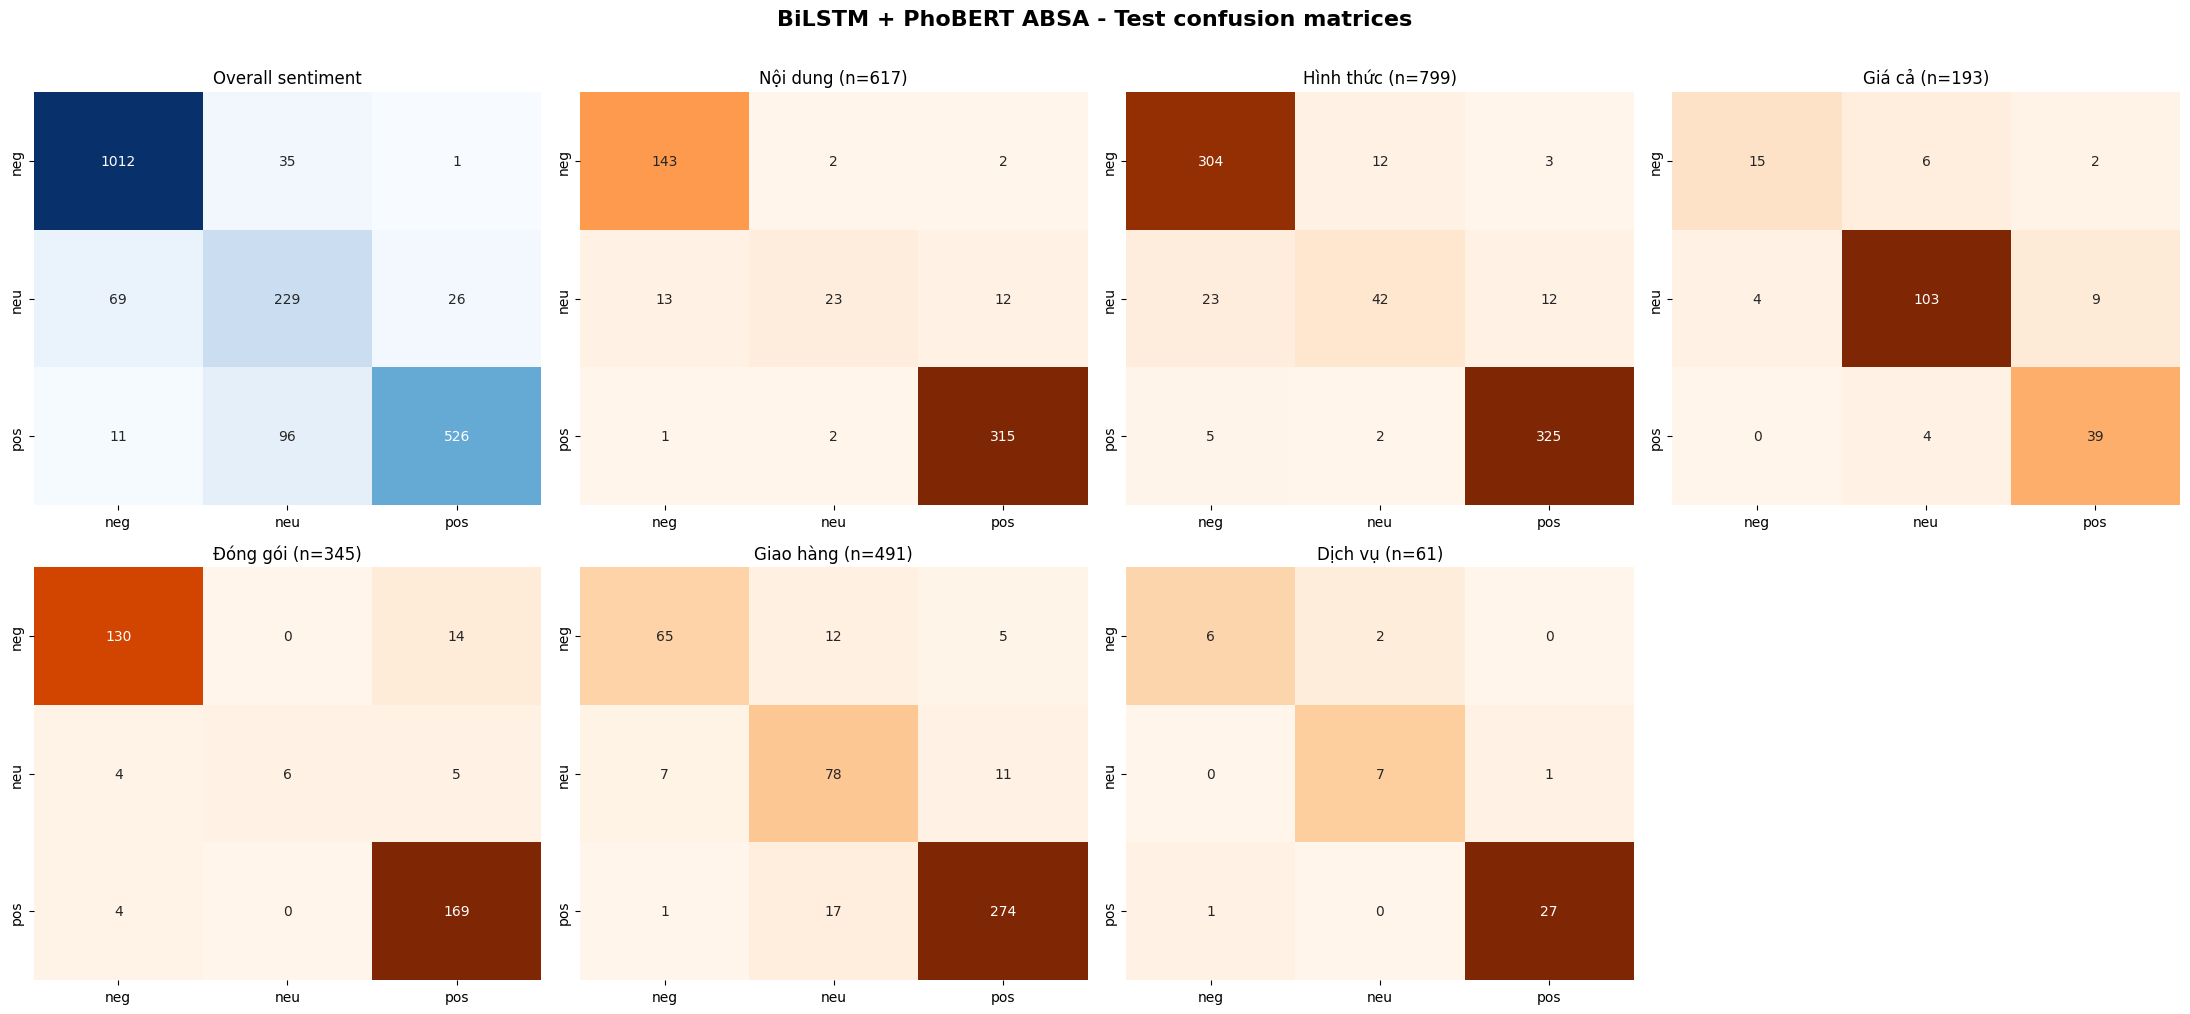

In [11]:
# Định nghĩa tên khía cạnh tiếng Việt để hiển thị cho đẹp
ASPECT_NAMES = ['Nội dung', 'Hình thức', 'Giá cả', 'Đóng gói', 'Giao hàng', 'Dịch vụ']
# Định nghĩa biến cho tên cột để lặp
ASPECT_COLS = ['as_content', 'as_physical', 'as_price', 'as_packaging', 'as_delivery', 'as_service']
ABSENT_CLASS = 3

def plot_confusion_matrices(true_sentiment: np.ndarray, pred_sentiment: np.ndarray, true_aspects: np.ndarray, pred_aspects: np.ndarray) -> None:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()

    # Nhãn cảm xúc: 0 (tiêu cực), 1 (trung tính), 2 (tích cực)
    sent_cm = confusion_matrix(true_sentiment, pred_sentiment, labels=[0, 1, 2])
    sns.heatmap(sent_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=axes[0])
    axes[0].set_title('Overall sentiment')

    for idx, col in enumerate(ASPECT_COLS):
        ax = axes[idx + 1]
        # Bỏ qua các khía cạnh không xuất hiện (ABSENT_CLASS = 3) trong nhãn thực tế
        mask = true_aspects[:, idx] != ABSENT_CLASS
        if mask.sum() == 0:
            ax.set_visible(False)
            continue

        cm = confusion_matrix(true_aspects[:, idx][mask], pred_aspects[:, idx][mask], labels=[0, 1, 2])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
                    xticklabels=['neg', 'neu', 'pos'], yticklabels=['neg', 'neu', 'pos'], ax=ax)
        ax.set_title(f'{ASPECT_NAMES[idx]} (n={mask.sum()})')

    # Ẩn ô cuối cùng nếu dư
    if len(axes) > 7:
        axes[7].set_visible(False)

    plt.suptitle('BiLSTM + PhoBERT ABSA - Test confusion matrices', y=1.01, fontweight='bold', fontsize=16)
    plt.tight_layout()

    # Lưu ảnh ma trận nhầm lẫn
    os.makedirs(OUTPUT_ROOT, exist_ok=True)
    plt.savefig(OUTPUT_ROOT / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
    plt.show()

# ==========================================
# THỰC THI ĐÁNH GIÁ TRÊN TẬP TEST
# ==========================================
print("Đang đánh giá mô hình BiLSTM + PhoBERT trên tập Test...")

# 1. Khởi tạo lại cấu trúc mô hình (Cần thiết trước khi load state_dict)
model = PhoBERT_ABSABiLSTM(HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(ASPECT_COLS)).to(DEVICE)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)

# 2. Khởi tạo lại Dataloader nếu nó đã bị xóa khỏi RAM (Safety check)
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
test_ldr = DataLoader(TextDatasetPhoBERT(test_df, tokenizer, MAX_LENGTH), batch_size=BATCH_SIZE_PHOBERT_EVAL)

# 3. Load trọng số từ file .pt đã lưu
state_dict = torch.load('/kaggle/working/absa_experiments/best_bilstm_+_phobert.pt', map_location=DEVICE)

if hasattr(model, 'module'):
    model.module.load_state_dict(state_dict)
else:
    model.load_state_dict(state_dict)

model.eval()

true_sentiment, pred_sentiment = [], []
true_aspects, pred_aspects = [], []

# Chuẩn bị biến đo lường thời gian
start_time = time.time()
num_steps = len(test_ldr)
num_samples = len(test_df)
test_loss_total = 0.0

# 4. Chạy suy luận (Inference) sử dụng test_ldr
with torch.no_grad():
    for batch in test_ldr:  
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        # Lấy Logits từ mô hình
        sent_logits, pres_logits, asp_logits = model(input_ids, attention_mask)
        
        # Tính Loss giả định (Nếu bạn muốn track chính xác, cần gọi hàm compute_individual_losses kết hợp awl_pb ở đây)
        # Tạm thời gán 0.0 để tương thích format bạn yêu cầu
        test_loss_total += 0.0 

        # Lấy nhãn dự đoán bằng argmax
        p_sent = sent_logits.argmax(dim=-1).cpu().numpy()
        p_pres = pres_logits.argmax(dim=-1).cpu().numpy()
        p_asp_sent = asp_logits.argmax(dim=-1).cpu().numpy()

        # Logic ghép nhãn: Nếu presence = 0 (không xuất hiện) -> gán nhãn ABSENT_CLASS (3)
        p_asp = np.where(p_pres == 0, ABSENT_CLASS, p_asp_sent)

        # Lưu trữ kết quả
        lbls_cpu = labels.cpu().numpy()
        true_sentiment.extend(lbls_cpu[:, 0])
        pred_sentiment.extend(p_sent)
        true_aspects.extend(lbls_cpu[:, 1:])
        pred_aspects.extend(p_asp)

# Tính toán các chỉ số về tốc độ suy luận
eval_runtime = time.time() - start_time
eval_samples_per_second = num_samples / eval_runtime
eval_steps_per_second = num_steps / eval_runtime

# Chuyển đổi sang Numpy Array
true_sentiment = np.array(true_sentiment)
pred_sentiment = np.array(pred_sentiment)
true_aspects = np.array(true_aspects)
pred_aspects = np.array(pred_aspects)

# BÁO CÁO TRUNG BÌNH TOÀN BỘ ASPECT (present only)
all_true = []
all_pred = []

for idx in range(len(ASPECT_COLS)):
    t_asp = true_aspects[:, idx]
    p_asp = pred_aspects[:, idx]
    mask = t_asp != ABSENT_CLASS  # chỉ lấy các aspect có xuất hiện
    if mask.sum() == 0:
        continue
    all_true.extend(t_asp[mask])
    all_pred.extend(p_asp[mask])

all_true = np.array(all_true)
all_pred = np.array(all_pred)

# TÍNH TOÁN CÁC CHỈ SỐ METRICS CHO DICTIONARY
eval_f1_sentiment = f1_score(true_sentiment, pred_sentiment, average='macro', labels=[0, 1, 2], zero_division=0)
eval_accuracy = accuracy_score(true_sentiment, pred_sentiment)
eval_f1_aspect_present = f1_score(all_true, all_pred, average='macro', labels=[0, 1, 2], zero_division=0) if len(all_true) > 0 else 0.0
eval_f1_aspect_all = f1_score(true_aspects.flatten(), pred_aspects.flatten(), average='macro', zero_division=0)
eval_f1_combined = (eval_f1_sentiment + eval_f1_aspect_present) / 2

# Tính F1 Macro cho từng khía cạnh riêng biệt
aspect_f1_dict = {}
for idx, col in enumerate(ASPECT_COLS):
    t_asp = true_aspects[:, idx]
    p_asp = pred_aspects[:, idx]
    mask = t_asp != ABSENT_CLASS
    if mask.sum() > 0:
        aspect_f1_dict[f'eval_f1_{col}'] = f1_score(t_asp[mask], p_asp[mask], average='macro', labels=[0, 1, 2], zero_division=0)
    else:
        aspect_f1_dict[f'eval_f1_{col}'] = 0.0

# THIẾT LẬP TỪ ĐIỂN CHỨA TEST METRICS
test_metrics = {
    'eval_f1_sentiment': eval_f1_sentiment,
    'eval_f1_aspect_all': eval_f1_aspect_all,
    'eval_f1_aspect_present': eval_f1_aspect_present,
    'eval_f1_combined': eval_f1_combined,
    'eval_accuracy': eval_accuracy,
    'eval_f1_as_content': aspect_f1_dict['eval_f1_as_content'],
    'eval_f1_as_physical': aspect_f1_dict['eval_f1_as_physical'],
    'eval_f1_as_price': aspect_f1_dict['eval_f1_as_price'],
    'eval_f1_as_packaging': aspect_f1_dict['eval_f1_as_packaging'],
    'eval_f1_as_delivery': aspect_f1_dict['eval_f1_as_delivery'],
    'eval_f1_as_service': aspect_f1_dict['eval_f1_as_service'],
    'eval_runtime': eval_runtime,
    'eval_samples_per_second': eval_samples_per_second,
    'eval_steps_per_second': eval_steps_per_second
}

# IN RA BÁO CÁO VÀ TEST METRICS
print('\n=========================================')
print('=== BÁO CÁO TỔNG THỂ (OVERALL SENTIMENT) ===')
print('=========================================')
print(classification_report(true_sentiment, pred_sentiment, labels=[0, 1, 2], target_names=['neg', 'neu', 'pos'], zero_division=0))

print('\n=========================================')
print('=== Báo Cáo Mean 6 ASPECTS')
print('=========================================')
print(classification_report(all_true, all_pred, labels=[0, 1, 2], target_names=['neg', 'neu', 'pos'], zero_division=0))

print('\n=========================================')
print('=== TEST METRICS ===')
print('=========================================')
print(f"Test metrics: {test_metrics}")

# Vẽ đồ thị ma trận nhầm lẫn
plot_confusion_matrices(true_sentiment, pred_sentiment, true_aspects, pred_aspects)

## DEMO

In [12]:
# Định nghĩa map nhãn
SENTIMENT_MAP = {0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực"}
ASPECT_NAMES_VI = ['Nội dung', 'Hình thức', 'Giá cả', 'Đóng gói', 'Giao hàng', 'Dịch vụ']

def predict_single_review_with_confidence(text, model, tokenizer, max_len=160): # Đảm bảo max_len khớp với lúc train
    model.eval()

    # 1. Tiền xử lý
    text_seg = ViTokenizer.tokenize(text.lower())

    # 2. Tokenization
    encoding = tokenizer(
        text_seg,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    # 3. Suy luận & Tính xác suất (Softmax)
    with torch.no_grad():
        sent_logits, pres_logits, asp_logits = model(input_ids, attention_mask)

        # Chuyển Logits thành Xác suất (Probabilities)
        sent_probs = F.softmax(sent_logits, dim=-1).cpu().numpy()[0]
        pres_probs = F.softmax(pres_logits, dim=-1).cpu().numpy()[0]
        asp_probs = F.softmax(asp_logits, dim=-1).cpu().numpy()[0]

        # Dự đoán Cảm xúc tổng thể (Vẫn dùng argmax vì đây là Multi-class)
        p_sent = sent_probs.argmax()
        sent_conf = sent_probs[p_sent] * 100

        # --- CẢI TIẾN: SỬ DỤNG THRESHOLD RIÊNG CHO TỪNG KHÍA CẠNH ---
        # 0:'Nội dung', 1:'Hình thức', 2:'Giá cả', 3:'Đóng gói', 4:'Giao hàng', 5:'Dịch vụ'
        # Thiết lập ngưỡng riêng (Tùy chỉnh theo lúc bạn phân tích file error_analysis.csv)
        ASPECT_THRESHOLDS = np.array([
            0.98,  # Nội dung: Ép thật cao (90%) vì mô hình rất hay đoán nhầm khía cạnh này
            0.40,  # Hình thức: Giữ vừa phải
            0.50,  # Giá cả
            0.30,  # Đóng gói: Hạ thấp để dễ bắt (30%)
            0.60,  # Giao hàng
            0.70   # Dịch vụ: Tăng lên chút để tránh nhận diện sai (như trong câu 2)
        ])

        # Lấy mảng xác suất của nhãn 1 (Có xuất hiện)
        prob_is_present = pres_probs[:, 1]

        # So sánh từng khía cạnh với ngưỡng tương ứng của nó
        p_pres = (prob_is_present >= ASPECT_THRESHOLDS).astype(int)

        # Cảm xúc của khía cạnh (Vẫn dùng argmax)
        p_asp_sent = asp_probs.argmax(axis=-1)

    # 4. In kết quả trực quan
    print("=" * 60)
    print(f"📝 BÌNH LUẬN GỐC : {text}")
    print(f"🔍 ĐÃ TÁCH TỪ    : {text_seg}")
    print("-" * 60)
    print(f"⭐ ĐÁNH GIÁ CHUNG: {SENTIMENT_MAP[p_sent]} (Độ tự tin: {sent_conf:.1f}%)")
    print("-" * 60)
    print("📌 CHI TIẾT CÁC KHÍA CẠNH:")

    aspect_count = 0
    for idx, aspect_name in enumerate(ASPECT_NAMES_VI):
        # Xác suất mô hình cho rằng khía cạnh này CÓ xuất hiện (nhãn 1)
        presence_conf = pres_probs[idx][1] * 100

        if p_pres[idx] == 0:
            # print(f"   ~ [Bỏ qua] {aspect_name:<10}: (Chỉ đạt {presence_conf:.1f}% xuất hiện)")
            continue
        else:
            aspect_count += 1
            sentiment_conf = asp_probs[idx][p_asp_sent[idx]] * 100
            print(f"   - {aspect_name:<10}: {SENTIMENT_MAP[p_asp_sent[idx]]:<15} | Tự tin nhận diện: {presence_conf:.1f}% | Tự tin cảm xúc: {sentiment_conf:.1f}%")

    if aspect_count == 0:
        print("   (Không phát hiện khía cạnh cụ thể nào)")
    print("=" * 60 + "\n")


# ==========================================
# KHU VỰC CHẠY THỬ (TEST INFERENCE)
# ==========================================

tokenizer_pb = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Load model (thay thế model_pb bằng biến mô hình thực tế của bạn)
state_dict = torch.load(OUTPUT_ROOT / 'best_bilstm_+_phobert.pt', map_location=DEVICE)
if hasattr(model_pb, 'module'):
    model_pb.module.load_state_dict(state_dict)
else:
    model_pb.load_state_dict(state_dict)

test_reviews = [
    "Sách bọc màng co cẩn thận, giao hàng siêu nhanh nhưng nội dung đọc hơi chán, không như kỳ vọng.",
    "bìa xinh lắm ạ vì mua vào ngày 11/11 nên săn sale rẻ, nhưng shipper thái độ quá tệ, cọc cằn rất khó chịu.",
    "Tôi thấy bình thường, mua về chưa đọc tới nên không biết bên trong thế nào."
]

for review in test_reviews:
    predict_single_review_with_confidence(review, model_pb, tokenizer_pb, max_len=160)

📝 BÌNH LUẬN GỐC : Sách bọc màng co cẩn thận, giao hàng siêu nhanh nhưng nội dung đọc hơi chán, không như kỳ vọng.
🔍 ĐÃ TÁCH TỪ    : sách bọc màng co cẩn_thận , giao hàng siêu nhanh nhưng nội_dung đọc hơi chán , không như kỳ_vọng .
------------------------------------------------------------
⭐ ĐÁNH GIÁ CHUNG: Trung tính (Độ tự tin: 92.4%)
------------------------------------------------------------
📌 CHI TIẾT CÁC KHÍA CẠNH:
   - Đóng gói  : Tích cực        | Tự tin nhận diện: 94.6% | Tự tin cảm xúc: 96.0%
   - Giao hàng : Tích cực        | Tự tin nhận diện: 99.5% | Tự tin cảm xúc: 98.1%

📝 BÌNH LUẬN GỐC : bìa xinh lắm ạ vì mua vào ngày 11/11 nên săn sale rẻ, nhưng shipper thái độ quá tệ, cọc cằn rất khó chịu.
🔍 ĐÃ TÁCH TỪ    : bìa xinh lắm ạ vì mua vào ngày 11 / 11 nên săn sale rẻ , nhưng shipper thái_độ quá tệ , cọc cằn rất khó_chịu .
------------------------------------------------------------
⭐ ĐÁNH GIÁ CHUNG: Tiêu cực (Độ tự tin: 62.5%)
----------------------------------------------

## Phân tích lỗi sai

In [13]:
print("Đang thu thập dự đoán trên tập Test để phân tích lỗi...")
model_pb.eval()
all_preds_sent = []
all_preds_asp = []

with torch.no_grad():
    for batch in test_ldr:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        sent_logits, pres_logits, asp_logits = model_pb(input_ids, attention_mask)

        # Lấy nhãn dự đoán
        p_sent = sent_logits.argmax(dim=-1).cpu().numpy()
        p_pres = pres_logits.argmax(dim=-1).cpu().numpy()
        p_asp_sent = asp_logits.argmax(dim=-1).cpu().numpy()
        p_asp = np.where(p_pres == 0, ABSENT_CLASS, p_asp_sent)

        all_preds_sent.extend(p_sent)
        all_preds_asp.extend(p_asp)

# ==========================================
# 2. TẠO DATAFRAME LƯU TRỮ KẾT QUẢ SO SÁNH
# ==========================================
error_analysis_df = test_df.copy()
error_analysis_df['pred_sentiment_llm'] = all_preds_sent

for i, col in enumerate(ASPECT_COLS):
    error_analysis_df[f'pred_{col}'] = np.array(all_preds_asp)[:, i]

# Map nhãn số sang text cho dễ đọc
LABEL_MAP = {0: "Tiêu cực", 1: "Trung tính", 2: "Tích cực", 3: "Không có"}
def map_labels_to_text(df, cols):
    for col in cols:
        df[col] = df[col].map(LABEL_MAP)
    return df

# Chuyển đổi nhãn thực tế và dự đoán sang Text
cols_to_map = ['sentiment_llm', 'pred_sentiment_llm'] + ASPECT_COLS + [f'pred_{col}' for col in ASPECT_COLS]
error_analysis_df = map_labels_to_text(error_analysis_df, cols_to_map)

# ==========================================
# 3. TÌM CÁC CÂU LỖI
# ==========================================
# Điều kiện lỗi: Cảm xúc chung sai HOẶC bất kỳ Aspect nào sai
is_error = (error_analysis_df['sentiment_llm'] != error_analysis_df['pred_sentiment_llm'])
for col in ASPECT_COLS:
    is_error = is_error | (error_analysis_df[col] != error_analysis_df[f'pred_{col}'])

df_errors = error_analysis_df[is_error].reset_index(drop=True)
print(f"Tổng số câu bị dự đoán sai (ít nhất 1 thành phần): {len(df_errors)} / {len(test_df)}")

# ==========================================
# 4. IN RA MỘT SỐ VÍ DỤ ĐIỂN HÌNH ĐỂ PHÂN TÍCH
# ==========================================
# Cài đặt số lượng sample muốn xem, ví dụ xem 5 câu lỗi ngẫu nhiên
NUM_SAMPLES_TO_VIEW = 5
sample_errors = df_errors.sample(min(NUM_SAMPLES_TO_VIEW, len(df_errors)), random_state=42)

for idx, row in sample_errors.iterrows():
    print("=" * 70)
    print(f" BÌNH LUẬN GỐC: {row['text_full']}")
    print("-" * 70)

    # Kiểm tra Cảm xúc chung
    if row['sentiment_llm'] != row['pred_sentiment_llm']:
        print(f" [SAI CẢM XÚC CHUNG] Thực tế: '{row['sentiment_llm']}' | Mô hình đoán: '{row['pred_sentiment_llm']}'")
    else:
        print(f" [ĐÚNG CẢM XÚC CHUNG] {row['sentiment_llm']}")

    print("\n CHI TIẾT KHÍA CẠNH:")
    for aspect_col, aspect_name in zip(ASPECT_COLS, ASPECT_NAMES):
        true_val = row[aspect_col]
        pred_val = row[f'pred_{aspect_col}']

        if true_val != pred_val:
            print(f"   {aspect_name:<10} -> Thực tế: '{true_val:<10}' | Mô hình đoán: '{pred_val}'")
        elif true_val != "Không có":
            # In ra những aspect đoán đúng để có ngữ cảnh
            print(f"    {aspect_name:<10} -> Đúng: '{true_val}'")

# (Tuỳ chọn) Lưu toàn bộ tập lỗi ra file CSV để xem trên Excel
ERROR_FILE = OUTPUT_ROOT / 'error_analysis.csv'
df_errors.to_csv(ERROR_FILE, index=False, encoding='utf-8-sig')
print("=" * 70)
print(f" Đã lưu toàn bộ các câu lỗi ra file: {ERROR_FILE} để bạn tiện phân tích sâu hơn.")

Đang thu thập dự đoán trên tập Test để phân tích lỗi...
Tổng số câu bị dự đoán sai (ít nhất 1 thành phần): 829 / 2005
 BÌNH LUẬN GỐC:  mình thấy cách hướng dẫn ứng xử với lại các mẩu chuyện dẫn dắt vào chủ đề có phần nào đó thảo mai và cứng nhắc. đọc mãi không vô nên bỏ dở giữa chừng luôn. kì vọng về cuốn này cao nên bị hụt hẫng khálớn hic :<
----------------------------------------------------------------------
 [ĐÚNG CẢM XÚC CHUNG] Tiêu cực

 CHI TIẾT KHÍA CẠNH:
   Nội dung   -> Thực tế: 'Tiêu cực  ' | Mô hình đoán: 'Không có'
 BÌNH LUẬN GỐC:  sách gì mà dính vào nhau, phải lấy dao dọc giấy ra tách ra. nhận sách thì bụi, phải lau lại cho sạch. chất giấy cũng kém, trông khá rẻ tiền.
----------------------------------------------------------------------
 [ĐÚNG CẢM XÚC CHUNG] Tiêu cực

 CHI TIẾT KHÍA CẠNH:
   Hình thức  -> Thực tế: 'Không có  ' | Mô hình đoán: 'Tiêu cực'
    Giá cả     -> Đúng: 'Trung tính'
 BÌNH LUẬN GỐC:  sách in màu đep, hình ảnh rõ nét. nội dung chỉ ghi vắn tắt sơ l